In [1751]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix
from sklearn.preprocessing import PowerTransformer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import  FunctionTransformer
from sklearn.preprocessing import OneHotEncoder

In [1752]:
dataset=pd.read_csv(r"C:\Users\rohit\Documents\Documents\langgraph\titanic_cleaned.csv")

In [1753]:
dataset.sample(10)

,Unnamed: 0,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Fare,Age,Deck,Embarked
182,200,201,0,3,male,0,0,9.5000,28.000000,C,S
280,306,307,1,1,female,0,0,110.8833,29.699118,C,C
167,184,185,1,3,female,0,2,22.0250,4.000000,C,S
641,696,697,0,3,male,0,0,8.0500,44.000000,C,S
440,475,476,0,1,male,0,0,52.0000,29.699118,A,S
613,665,666,0,2,male,2,0,73.5000,32.000000,C,S
249,271,272,1,3,male,0,0,0.0000,25.000000,C,S
622,675,676,0,3,male,0,0,7.7750,18.000000,C,S
601,652,653,0,3,male,0,0,8.4333,21.000000,C,S
206,225,226,0,3,male,0,0,9.3500,22.000000,C,S


In [1754]:
dataset.columns

Index(['Unnamed: 0', 'PassengerId', 'Survived', 'Pclass', 'Sex', 'SibSp',
       'Parch', 'Fare', 'Age', 'Deck', 'Embarked'],
      dtype='object')

In [1755]:
dataset=dataset.drop("Unnamed: 0",axis=1)

In [1756]:
dataset.sample(10)

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Fare,Age,Deck,Embarked
685,741,1,1,male,0,0,30.0000,29.699118,D,S
613,666,0,2,male,2,0,73.5000,32.000000,C,S
449,487,1,1,female,1,0,90.0000,35.000000,C,S
156,170,0,3,male,0,0,56.4958,28.000000,C,S
330,359,1,3,female,0,0,7.8792,29.699118,C,Q
433,467,0,2,male,0,0,0.0000,29.699118,C,S
567,613,1,3,female,1,0,15.5000,29.699118,C,Q
603,655,0,3,female,0,0,6.7500,18.000000,C,Q
602,654,1,3,female,0,0,7.8292,29.699118,C,Q
348,378,0,1,male,0,2,211.5000,27.000000,C,C


In [1757]:
dataset.shape[0]

825

In [1758]:
dataset.size

8250

In [1759]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  825 non-null    int64  
 1   Survived     825 non-null    int64  
 2   Pclass       825 non-null    int64  
 3   Sex          825 non-null    object 
 4   SibSp        825 non-null    int64  
 5   Parch        825 non-null    int64  
 6   Fare         825 non-null    float64
 7   Age          825 non-null    float64
 8   Deck         825 non-null    object 
 9   Embarked     825 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 64.6+ KB


In [1760]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
SibSp          0
Parch          0
Fare           0
Age            0
Deck           0
Embarked       0
dtype: int64

In [1761]:
count_sex=dataset["Sex"].value_counts()
for x in dataset["Sex"].unique():
    print(f"The percentage of the {x} class is: ",(count_sex[x]/dataset.shape[0])*100,"%")


The percentage of the male class is:  64.36363636363637 %
The percentage of the female class is:  35.63636363636364 %


In [1762]:
dataset.duplicated().sum()

np.int64(0)

In [1763]:
dataset.drop("Survived",axis=1).describe()

,PassengerId,Pclass,SibSp,Parch,Fare,Age
count,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000
mean,447.369697,2.341818,0.507879,0.357576,31.483615,28.879689
std,257.088865,0.824096,1.090670,0.798599,49.956429,10.182710
min,1.000000,1.000000,0.000000,0.000000,0.000000,3.000000
25%,226.000000,2.000000,0.000000,0.000000,7.895800,22.000000
50%,445.000000,3.000000,0.000000,0.000000,13.416700,29.699118
75%,671.000000,3.000000,1.000000,0.000000,30.070800,34.000000
max,891.000000,3.000000,8.000000,6.000000,512.329200,54.000000


In [1764]:
dataset.drop("Survived",axis=1).corr(numeric_only=True)

,PassengerId,Pclass,SibSp,Parch,Fare,Age
PassengerId,1.000000,-0.034032,-0.053075,-0.006142,0.015231,0.048444
Pclass,-0.034032,1.000000,0.057760,0.018742,-0.552684,-0.286128
SibSp,-0.053075,0.057760,1.000000,0.408487,0.166625,-0.182124
Parch,-0.006142,0.018742,0.408487,1.000000,0.190001,-0.131052
Fare,0.015231,-0.552684,0.166625,0.190001,1.000000,0.091278
Age,0.048444,-0.286128,-0.182124,-0.131052,0.091278,1.000000


## EDA

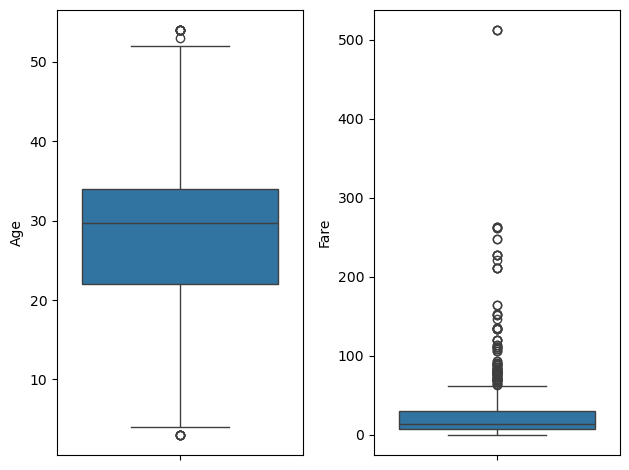

In [1765]:
plt.subplot(1,2,1)
sns.boxplot(dataset["Age"])
plt.subplot(1,2,2)
sns.boxplot(dataset["Fare"])
plt.tight_layout()
plt.show()

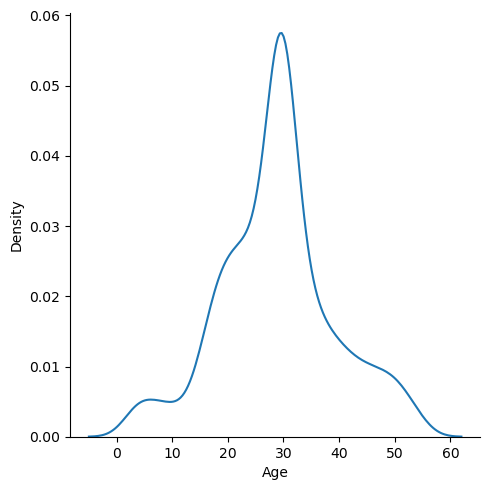

In [1766]:
sns.displot(x=dataset["Age"],kind="kde")

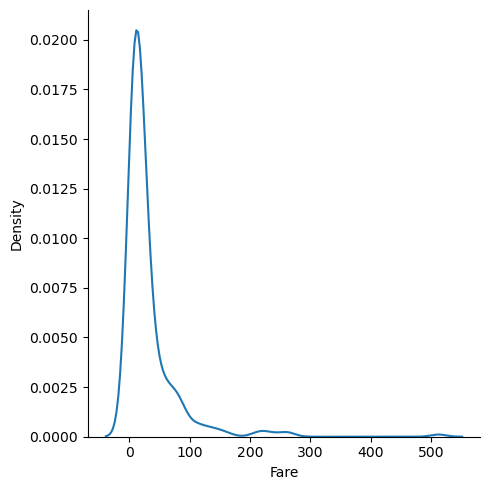

In [1767]:
sns.displot(x=dataset["Fare"],kind="kde")

In [1768]:
y=dataset["Survived"]
X=dataset.drop("Survived",axis=1)


In [1769]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Power Transform on Age

In [1770]:
transformer=PowerTransformer(method="yeo-johnson")


In [1771]:
transformer.fit(X_train[["Age"]])

age_transformed_train=transformer.transform(X_train[["Age"]])

age_transformed_test=transformer.transform(X_test[["Age"]])

print(pd.Series(age_transformed_train.ravel()).skew())

print(pd.Series(age_transformed_test.ravel()).skew())


0.016808724994252185
0.2707396615144319


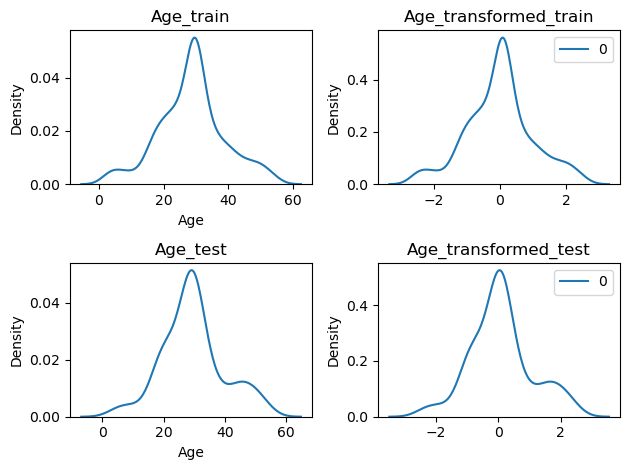

In [1772]:
plt.subplot(2,2,1)
sns.kdeplot(X_train["Age"])
plt.title("Age_train")
plt.subplot(2,2,2)
sns.kdeplot(age_transformed_train)
plt.title("Age_transformed_train")

plt.subplot(2,2,3)
sns.kdeplot(X_test["Age"])
plt.title("Age_test")
plt.subplot(2,2,4)
sns.kdeplot(age_transformed_test)
plt.title("Age_transformed_test")

plt.tight_layout()

plt.show()



In [1773]:
X_train["Age"]=age_transformed_train
X_test["Age"]=age_transformed_test


## Function Transformer on Age

In [1774]:
transformer=FunctionTransformer(func=np.log1p)


In [1775]:
transformer.fit(X_train[["Age"]])

age_transformed_train=transformer.transform(X_train[["Age"]])

age_transformed_test=transformer.transform(X_test[["Age"]])


print(age_transformed_train.skew())

print(age_transformed_test.skew())


Age   -1.518106
dtype: float64
Age   -1.453078
dtype: float64


c:\Users\rohit\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
c:\Users\rohit\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


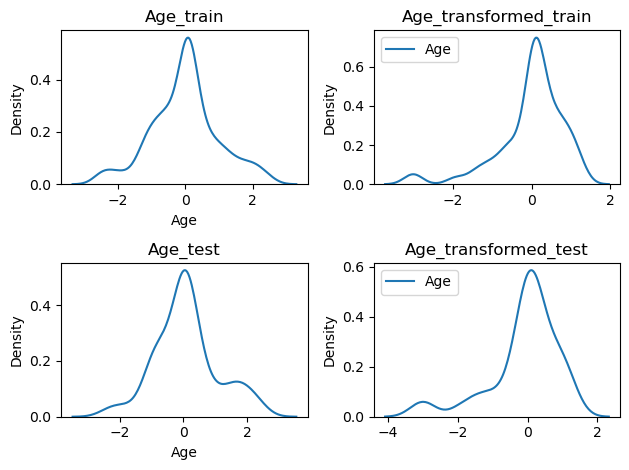

In [1776]:
plt.subplot(2,2,1)
sns.kdeplot(X_train["Age"])
plt.title("Age_train")
plt.subplot(2,2,2)
sns.kdeplot(age_transformed_train)
plt.title("Age_transformed_train")

plt.subplot(2,2,3)
sns.kdeplot(X_test["Age"])
plt.title("Age_test")
plt.subplot(2,2,4)
sns.kdeplot(age_transformed_test)
plt.title("Age_transformed_test")

plt.tight_layout()

plt.show()

## Power Transformer on Fare

In [1777]:
transformer=PowerTransformer(method="yeo-johnson")

In [1778]:
transformer.fit(X_train[["Fare"]])

,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True


In [1779]:
fare_transformed_train=transformer.transform(X_train[["Fare"]])
fare_transformed_test=transformer.transform(X_test[["Fare"]])

print(pd.Series(fare_transformed_train.ravel()).skew())
print(pd.Series(fare_transformed_test.ravel()).skew())

-0.06871807952887217
-0.773297394393511


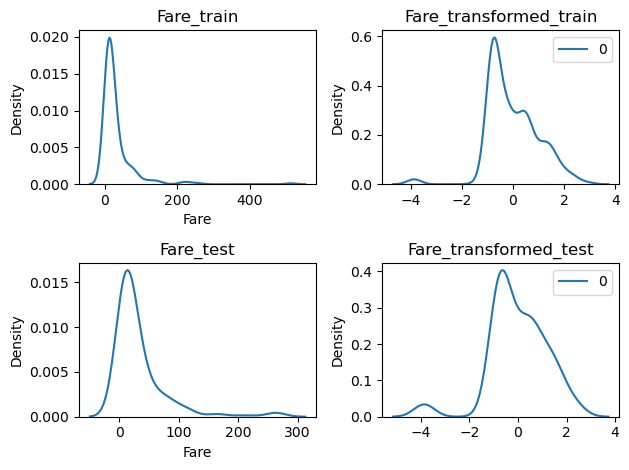

In [1780]:
plt.subplot(2,2,1)
sns.kdeplot(X_train["Fare"])
plt.title("Fare_train")
plt.subplot(2,2,2)
sns.kdeplot(fare_transformed_train)
plt.title("Fare_transformed_train")

plt.subplot(2,2,3)
sns.kdeplot(X_test["Fare"])
plt.title("Fare_test")
plt.subplot(2,2,4)
sns.kdeplot(fare_transformed_test)
plt.title("Fare_transformed_test")


plt.tight_layout()


## Function Transformer on Fare

In [1781]:
transformer=FunctionTransformer(func=np.log1p)

In [1782]:
transformer.fit(X_train[["Fare"]])

fare_transformed_train=transformer.transform(X_train[["Fare"]])

fare_transformed_test=transformer.transform(X_test[["Fare"]])


print(fare_transformed_train.skew())

print(fare_transformed_test.skew())


Fare    0.581017
dtype: float64
Fare   -0.046414
dtype: float64


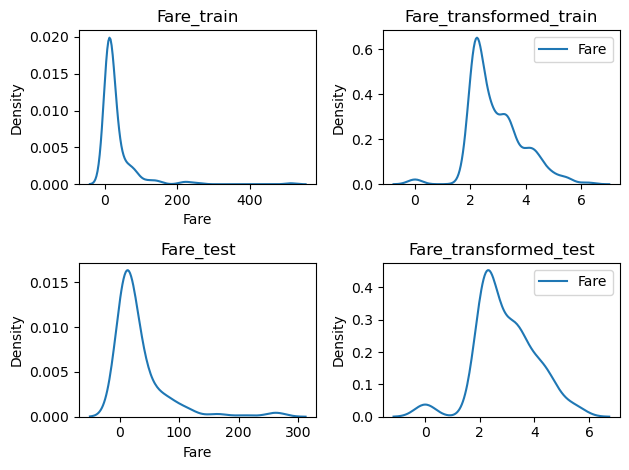

In [1783]:
plt.subplot(2,2,1)
sns.kdeplot(X_train["Fare"])
plt.title("Fare_train")
plt.subplot(2,2,2)
sns.kdeplot(fare_transformed_train)
plt.title("Fare_transformed_train")

plt.subplot(2,2,3)
sns.kdeplot(X_test["Fare"])
plt.title("Fare_test")
plt.subplot(2,2,4)
sns.kdeplot(fare_transformed_test)
plt.title("Fare_transformed_test")


plt.tight_layout()


In [1784]:
X_train["Fare"]=fare_transformed_train
X_test["Fare"]=fare_transformed_test

In [1785]:
X_train.sample(10)

,PassengerId,Pclass,Sex,SibSp,Parch,Fare,Age,Deck,Embarked
242,264,1,male,0,0,0.000000,1.106084,B,S
489,530,2,male,2,1,2.525729,-0.558605,C,S
104,114,3,female,1,0,2.381858,-0.852279,C,S
461,502,3,female,0,0,2.169054,-0.754392,C,Q
435,471,3,male,0,0,2.110213,0.097296,C,S
735,795,3,male,0,0,2.185579,-0.362803,C,S
614,667,2,male,0,0,2.639057,-0.362803,C,S
588,637,3,male,0,0,2.188856,0.322603,C,S
233,255,3,female,0,2,3.054591,1.204030,C,S
694,751,2,female,1,1,3.178054,-2.417671,C,S


In [1786]:
X_test.sample(10)

,PassengerId,Pclass,Sex,SibSp,Parch,Fare,Age,Deck,Embarked
445,482,2,male,0,0,0.000000,0.097296,C,S
39,45,3,female,0,0,2.183711,-0.950163,C,Q
110,122,3,male,0,0,2.202765,0.097296,C,S
29,35,1,male,1,0,4.420896,-0.069076,C,C
501,543,3,female,4,2,3.474293,-1.733048,C,S
677,733,2,male,0,0,0.000000,0.097296,C,S
54,61,3,male,0,0,2.107689,-0.656500,C,C
742,802,2,female,1,1,3.305054,0.224679,C,S
811,877,3,male,0,0,2.383778,-0.852279,C,S
101,111,1,male,0,0,3.970292,1.791745,C,S


## Encoding

In [1787]:
encoder=OneHotEncoder()
encoder.fit(X_train[["Sex","Deck","Embarked"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

In [1788]:
Object_transformed_train=encoder.transform(X_train[["Sex","Deck","Embarked"]]).toarray()
Object_transformed_test=encoder.transform(X_test[["Sex","Deck","Embarked"]]).toarray()

In [1789]:
encoder.get_feature_names_out()

array(['Sex_female', 'Sex_male', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D',
       'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'], dtype=object)

In [1790]:
X_train=X_train.drop(["Sex","Deck","Embarked"],axis=1)
X_test=X_test.drop(["Sex","Deck","Embarked"],axis=1)


In [1791]:
X_train[list(encoder.get_feature_names_out())]=np.int64(Object_transformed_train)
X_test[list(encoder.get_feature_names_out())]=np.int64(Object_transformed_test)

In [1792]:
print("____________X_train____________")
print(X_train.head(10))
print("____________X_test_____________")
print(X_test.head(10))

____________X_train____________
     PassengerId  Pclass  SibSp  Parch      Fare       Age  Sex_female  \
239          261       3      0      0  2.169054  0.097296           0   
689          745       3      0      0  2.188856  0.224679           0   
644          700       3      0      0  2.157559  1.301977           0   
342          372       3      1      0  2.014343 -1.048041           0   
299          326       1      0      0  4.917301  0.714325           1   
383          415       3      0      0  2.188856  1.497879           0   
79            87       3      1      3  3.566005 -1.243785           0   
148          161       3      0      1  2.839078  1.497879           0   
363          395       3      0      2  2.873565 -0.460706           1   
227          248       2      0      2  2.740840 -0.460706           1   

     Sex_male  Deck_A  Deck_B  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  \
239         1       0       0       1       0       0       0       0   

### Model Training

## Question - 4

In [1793]:
tree_accuracy=0
depth=0

for x in range(1,11):
    tree_classifier=DecisionTreeClassifier(criterion="gini",min_samples_split=5,max_depth=x)
    tree_classifier.fit(X_train,y_train)
    prediction_dt=tree_classifier.predict(X_test)
    if(accuracy_score(prediction_dt,y_test)*100>tree_accuracy):
        tree_accuracy=accuracy_score(prediction_dt,y_test)*100
        depth=x

    
    

   


In [1794]:
print(f"The Decision tree model achieved a highest accuracy of {tree_accuracy:.2f}% at tree depth: {depth}")


The Decision tree model achieved a highest accuracy of 83.64% at tree depth: 3


In [1795]:
tree_classifier=DecisionTreeClassifier(criterion="gini",min_samples_split=5,max_depth=3)

In [1796]:
tree_classifier.fit(X_train,y_train)
tree_classifier.get_depth()



3

In [1797]:
knn_accuracy=0
k=0

for x in range(1,20):
    knn_classifier=KNeighborsClassifier(n_neighbors=x)
    knn_classifier.fit(X_train,y_train)
    prediction_knn=knn_classifier.predict(X_test)
    if(accuracy_score(prediction_knn,y_test)*100>knn_accuracy):
        knn_accuracy=accuracy_score(prediction_knn,y_test)*100
        k=x

    
    

   


In [1798]:
print(k)
print(knn_accuracy)

2
60.0


In [1799]:
knn_classifier=KNeighborsClassifier(n_neighbors=4)
knn_classifier.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [1800]:
prediction_dt=tree_classifier.predict(X_test)
prediction_knn=knn_classifier.predict(X_test)

In [1801]:
accuracy_dt=accuracy_score(prediction_dt,y_test)*100
accuracy_knn=accuracy_score(prediction_knn,y_test)*100

## Question - 3

### Testing

In [1802]:
if(accuracy_dt>accuracy_knn):
    print(f"The Decision tree model performed better than KNN model with an accuracy of: {accuracy_dt:.2f}% ")
elif(accuracy_knn>accuracy_dt):
         print(f"The KNN model performed better than Decision Tree model with an accuracy of: {accuracy_knn:.2f}%")
else:
       print(f"Both models achieved a same accuracy of: {accuracy_dt:.2f}%")         

The Decision tree model performed better than KNN model with an accuracy of: 83.64% 
